# Building a 2D CNN for Image Classification
In this tutorial, we will be learning how to build a 2D version of a Convolutional Neural Network (CNN).


For this example, we will again be using the same dataset of histological images: http://dx.doi.org/10.5281/zenodo.53169. 

# Imports
Start by importing the packages and modules we will be needing for this project.

In [1]:
# Basic operating system (os), numerical, and plotting functionality
import os
import numpy as np
import matplotlib.pyplot as plt

# scikit-learn data utilities
from sklearn.model_selection import train_test_split
import skimage.transform as image_transform

# Color transformations
from skimage.color import rgb2lab

# scikit-learn performance metric utilities
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# pytorch for the CNN
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
# Set plotting preferences
import matplotlib
%matplotlib inline
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 16}
matplotlib.rc('font', **font)

# Retrieve and Load the Data
The following cell checks if the histological images have already been downloaded into the current Colab session and downloads them if not.

In [3]:
import urllib.request

# Define the current directory and the directory where the files to download can
# be found
current_dir = os.getcwd()
remote_path = 'https://github.com/BeaverWorksMedlytics2020/Data_Public/raw/master/NotebookExampleData/Week3/data_nuclei/crc/'

# Define and build a directory to save this data in
data_dir = './crc_data'
if not os.path.isdir(data_dir):
  os.mkdir(data_dir)
  
  # Move into the data directory and download all of the files
  os.chdir(data_dir)
  for ii in range(1, 6):
      basename = f'rgb0{ii}.npz'
      filename = os.path.join(remote_path, basename)

      # Check if the file has already been downloaded
      if not os.path.isfile(basename):
        print(f"loading: {filename}")
        urllib.request.urlretrieve(filename, basename)

  # Return to the original directory
  os.chdir(current_dir)

The downloaded ".npz" archives can now be read into memory and parsed using our data loading function copied from the previous tutorial.

In [4]:
# Define a function to load the data from the assumed download path
def load_images(colorspace='rgb'):
    """
    Loads the example data and applies transformation into requested colorspace

    Arguments
    ---------
    colorspace : str, optional, default: `rgb`
        The colorspace into which the images should be transformed. Accepted
        values include

        'rgb' : Standard red-green-blue color-space for digital images

        'gray' or 'grey': An arithmetic average of the (r, g, b) values

        'lab': The CIE L* a* b* colorspace
    
    Returns
    -------
    images : numpy.ndarray, shape (Nimg, Ny, Nx, Ncolor)
        The complete set of transformed images

    labels : numpy.ndarray, shape (Nimg)
        The classification labels associated with each entry in `images`

    label_to_str : dict
        A dictionary which converts the numerical classification value in
        `labels` into its string equivalent representation.
    """
    # Check that the colorspace argument is recognized
    colorspace_lower = colorspace.lower()
    if colorspace_lower not in ['rgb', 'gray', 'grey', 'lab']:
        raise ValueError(f'`colorspace` value of {colorspace} not recognized')

    # Load data, which is stored as a numpy archive file (.npz)
    filename = os.path.join(data_dir, 'rgb01.npz')
    print(f'loading {filename}')
    tmp = np.load(os.path.join(data_dir, 'rgb01.npz'), allow_pickle=True)

    # Parse the loaded data into images and labels
    # Initialize the images and labels variables using the first archive data
    images = tmp['rgb_data']
    if colorspace_lower == 'rgb':
        pass
    elif colorspace_lower in ['gray', 'grey']:
        images = np.mean(images, axis=-1)      # Average into grayscale
    elif colorspace_lower == 'lab':
        images = rgb2lab(images)               # Convert to CIE L*a*b*

    # Grab the initial array for the image labels
    labels = tmp['labels']
    
    # Grab the dictionary to convert numerical labels to their string equivalent
    label_to_str = tmp['label_str']
    label_to_str = label_to_str.tolist() # Convert label_to_str into a dict

    # Update the user on the number and size of images loaded
    print('Loaded images with shape {}'.format(images.shape))
    del tmp

    # Loop over each of the remaining archives and append the contained data
    for ii in range(2,6):
        # Build the full path to the archive and load it into memory
        filename = os.path.join(data_dir, f'rgb0{ii}.npz')
        print(f'loading {filename}')
        tmp = np.load(filename, allow_pickle=True)

        # Parse and append the data
        these_images = tmp['rgb_data']
        if colorspace_lower == 'rgb':
            pass
        elif (colorspace_lower == 'gray') or (colorspace_lower == 'grey'):
            these_images = np.mean(these_images, axis=-1) # Convert to grayscale
        elif colorspace_lower == 'lab':
            these_images = rgb2lab(these_images)          # Convert to CIEL*a*b*

        # Append the images and labels
        images = np.append(images, these_images, axis=0)
        labels = np.append(labels, tmp['labels'], axis=0)

        # Update the user on the number and size of images
        print('Loaded images with shape {}'.format(these_images.shape))
        del tmp

    # Force the image data to be floating point and print the data shape
    images = images.astype(np.float)
    print('Final image data shape: {}'.format(images.shape))
    print('Number of image labels: {}'.format(*labels.shape))

    return images, labels, label_to_str

With this data-loading function defined, let's load in the grayscale images.

In [5]:
# Load the data using our data-loading function
#
# You can change the `colorspace` keyword argument in `load_images` function
# call to try to try training classifier an image in another colorspace
images_full_res, labels, label_to_str = load_images(colorspace='gray')
num_classes = np.unique(labels).size

loading ./crc_data\rgb01.npz
Loaded images with shape (1000, 150, 150)
loading ./crc_data\rgb02.npz
Loaded images with shape (1000, 150, 150)
loading ./crc_data\rgb03.npz
Loaded images with shape (1000, 150, 150)
loading ./crc_data\rgb04.npz
Loaded images with shape (1000, 150, 150)
loading ./crc_data\rgb05.npz
Loaded images with shape (1000, 150, 150)


C:\Users\user\AppData\Local\Temp\ipykernel_24680\2974973199.py:86: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  images = images.astype(np.float)


Final image data shape: (5000, 150, 150)
Number of image labels: 5000


# Pre-process the Images

The following cells apply some pre-processing steps to the image data.

## Resize the Images for Faster Training

In the following cell, we resize the images so that they are lower resolution than the originals. This only has a minimal impact on the classifier performance, but it significantly accelerates training.

In [6]:
# Grab the original shape of the images
num_images = images_full_res.shape[0]

# Specify a new shape to use for the resized images
# NOTE: This can be modified to trade-off between training-speed and performance
original_shape = images_full_res.shape
new_shape = list(original_shape)
new_shape[1:3] = (48, 48)

# Initialize an array for storing the resized images
images = np.zeros(new_shape)

# Loop over each image in the data and perform a resizing operation
for img_num, img_data in enumerate(images_full_res):
    images[img_num] = image_transform.resize(img_data, new_shape[1:])

# Remove the full-resolution versions from memory (just glogging things up)
del images_full_res

## Normalize the Image Data
All images should be normalized to the range $\left[0, 1\right]$. The procedure for this will depend on the current colorspace of the images, but some basic guidelines follow:

* **RGB and greyscale:** images are often represented with integers in the range $\left[0, 255\right]$, so dividing by $255$ will often normalize these images (if they are not already normalized).

* **HSV, HSI, HSL:** the Hue (H) channel will typically be represnted by a number in the range $\left[0^{\circ}, 360^{\circ}\right)$. The Saturation channel channels will often be represented on a scale from $\left[0, 1\right]$, in which case no normalization is required. The final channel (Value, Intensity, or Lightness) is often represented by a snumber in the range of either $\left[0, 1\right]$ or $\left[0, 100\right]$, so a simple investigation should indicate what normalization may be needed for that channel.

* **CIE L\*a\*b\*:** The L\* channel often has a range of $\left[0, 100\right]$ while the a\* and b\* channels are in the range $\left[-100, +100\right]$. In some cases, the data may be represented by signed 8-bit integers, in which case the range of values is acutally maped to the discrete space from $\left[-128, +127\right]$, so you may need to examine if your data is integer or float.

In [7]:
# In this notebook, we are only considering greyscale and RGB data, so we
# normalize by dividing by 255. If you transform the images into a different 
# colorspace, you will need to edit this code to properly normalize the data.
if images.max() > 1:
    images = images.astype(np.float32)/255.0

## Include an Axis for Color Channels

Pytorch expects inputs of shape (N, C_in, H, W)


N = batch size

C_in = number of input channels

H = image height

W = image width

However, because we're using greyscaled images, there is no color channel. But since Pytorch is still expecting one, we still need to add it. 

In [8]:
# Take note of number of color channels in the loaded image add a last axis to 
# images ndarray if array dimension is only 3 (as is the case with grayscale images)
if images.ndim == 3:
    n_channels = 1
    # If image is grayscale, then we add a last axis (of len 1) for channel
    images = images[:, np.newaxis, : , :]
    print('\nlast dimension added to images ndarray to account for channel')
    print(f'new images.shape: {images.shape}')
else:
    #if image is not grayscale, last dimension of image already corresponds to channel
    n_channels = images.shape[-1]


last dimension added to images ndarray to account for channel
new images.shape: (5000, 1, 48, 48)


## Split the Image and Label Data
Now we can split our pre-processed data into a training and test set.

In [9]:
# Split into training and testing sets
tmp = train_test_split(images, labels, test_size = 0.2)
X_train, X_test, y_train, y_test = tmp

# Print sizes of train/test sets
print(f'X_train.shape: {X_train.shape}')
print(f'y_train.shape: {y_train.shape}')
print(f'X_test.shape: {X_test.shape}')
print(f'y_test.shape: {y_test.shape}')

X_train.shape: (4000, 1, 48, 48)
y_train.shape: (4000,)
X_test.shape: (1000, 1, 48, 48)
y_test.shape: (1000,)


# Building our CNN
At this point, the data has been split into training and testing sets and normalized. We will now design a fully connected neural network for texture classification. 

> #### Discussion question: 
> Here's an open research question--recall that a convolution operation can be expressed as a matrix multiplication
> 
> 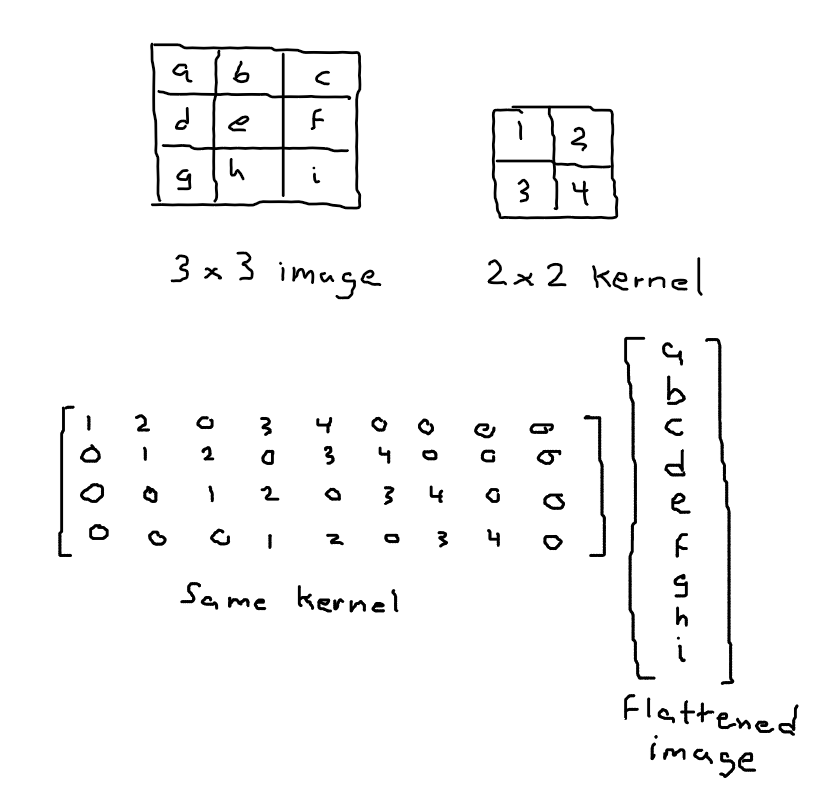
> 
> Since we expressed this convolution as a 4 by 9 matrix multipication--that means a linear layer with a 4 by 9 weight matrix can also express this same convolution AND many other operations. That means a convolution is just a subset of the set of all operations a linear layer can learn. 
> 
> Yet--empirically--a convolutional neural network will almost always out perform a fully connected neural network. 
> 
> What are some possible explanations? Take a minute to ponder on this. 
>
><details>
>  <summary>Answer</summary>
>  
>  The exact reason why this happens is not well understood to us, but there are some possible explanations. 
> 
>  One early explanation is that because the weight matrix of a convolution has fewer learnable parameters than the weight matrix of a linear layer, we have fewer parameters and therefore are less likely to overfit. 
>
> 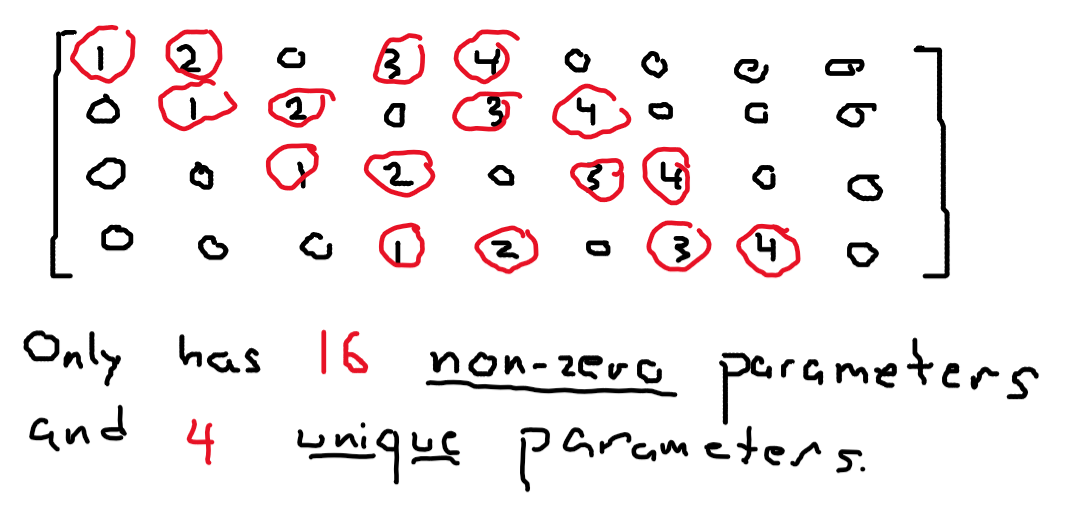
> 
>  This is rational, but if that was the case, we could just as easily randomly remove learnable parameters from a linear layer's weight matrix to get a sparse weight matrix like so. 
> 
> 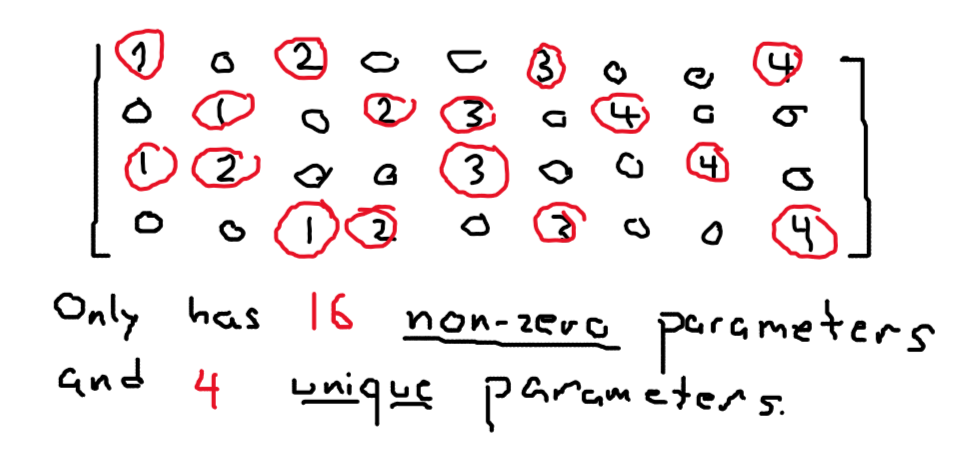
> 
> But you would find that this new sparse-linear weight matrix wouldn't be achieve similar performance to a convolution. This means the performance improvement isn't due to this alone. 
> 
>  This tells us that (1) there's something about the spatial relationship between pixels in images that is well aligned with convolution operations and that (2) a convolution layer is much more likely to find a good, generalizable solution than a linear layer is on these images. Beyond that remains an open research question
></details>

In [10]:
# Create your network
# TODO: replace me with something else
#       just an example, feel free to go crazy

model = nn.Sequential(
    nn.Conv2d(1, 16, 8, padding='valid'),
    nn.ReLU(),
    nn.MaxPool2d((10, 10), stride=3),

    nn.Conv2d(16, 32, 4, stride=1, padding='valid'),
    nn.ReLU(),
    nn.MaxPool2d((5, 5), stride=1),


    nn.Flatten(),
    nn.Linear(512,num_classes)
)

### What do CNNs learn?

Let's take a second to discuss the general design pattern of CNNs

One way of thinking about images is as a data structure that contains a hierarchy of spatial relationships. 


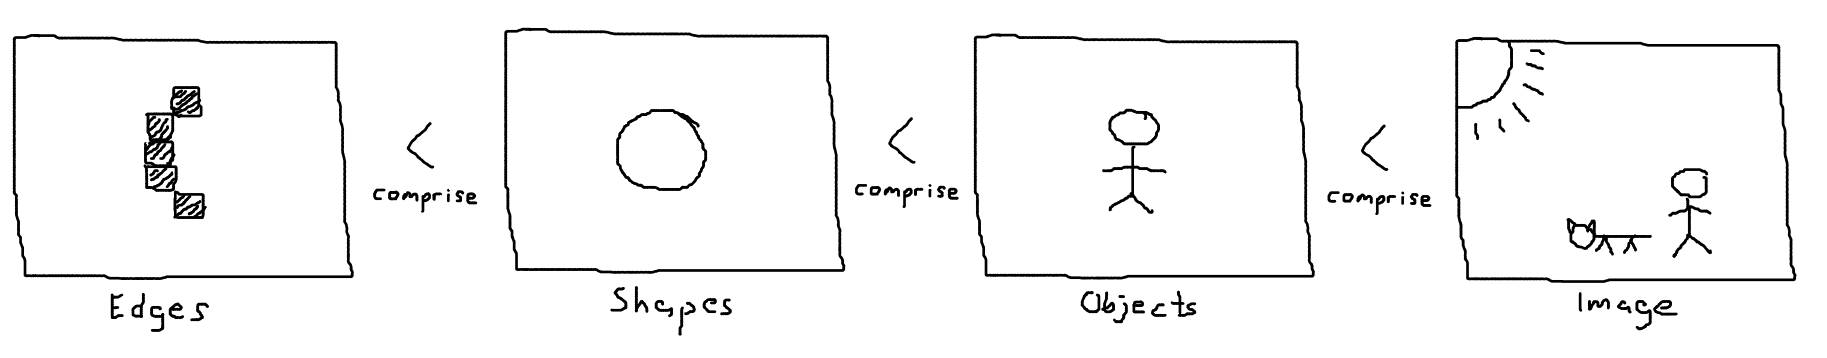

Edges form shapes.
Shapes form objects.
Objects form images.

The many layers of a CNN are well sutied to learning these hierarchical relationships. The general intuition is that earlier layers tend to learn basic features such as vertical edges and horizontal edges, while deeper layers learn abstract features such as object detectors. 

This makes sense if you think about it---the first layer of a CNN only has the original image to work with, so whatever features it learns has to be simple and easy--hence edge detectors which can be implemented in a single kernel. Meanwhile, something as abstract as say a "person detector" would need many many layers to implement and therefore, can only exist once we get deeper into the network. 

This intuition is reflected in how we tend to design convolutional neural networks.

![Example of a CNN Diagram](https://github.com/BeaverWorksMedlytics2020/Data_Public/raw/master/Images/Week3/CNN-example-block-diagram.jpg)

Notice that as we get deeper and deeper, the number of filters (also caled kernel) get higher while the size of each filter gets smaller. There are only so many possible basic edges you can learn in earlier layers, so these tend to have fewer filters--one filter for each edge type. 

But in the same way there are few atoms, but by rearranging them in different ways you can get millions of unique compounds and molecules, there are many many posisble shapes and objects these edges can form. And so deeper layers have more filters to account for this, while filter sizes get smaller (to account for decreasing image size). 

## Train the Model

In [11]:
epochs = 10
batch_size = 200

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

train = torch.utils.data.TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

train_loader = torch.utils.data.DataLoader(train, batch_size=batch_size, shuffle=False)

for epoch in range(epochs):
    for i, data in enumerate(train_loader):
        # Train loop
        model.train()
        inputs, labels = data

        # Pytorch keeps track of gradients across loops, so we need to zero it for each batch
        # We need to manually zero the gradient--reset it--every batch
        optimizer.zero_grad()
 
        outputs = model(inputs) # Get the model's output
        loss = criterion(outputs, labels) # Compute the loss
        preds = torch.argmax(outputs,dim=1)

        # For monitoring
        tr_loss = loss.item()
        tr_acc = torch.sum(preds==labels)/len(labels)

        loss.backward() # Backpropagate to compute gradient
        optimizer.step() # Update the parameters, according to chosen optimizer algorithm

    print(f'Train loss: {tr_loss:.3f}, Train Accurayc: {tr_acc:.3f}')

Train loss: 1.485, Train Accurayc: 0.390
Train loss: 1.301, Train Accurayc: 0.500
Train loss: 1.243, Train Accurayc: 0.510
Train loss: 1.229, Train Accurayc: 0.525
Train loss: 1.217, Train Accurayc: 0.545
Train loss: 1.133, Train Accurayc: 0.580
Train loss: 1.184, Train Accurayc: 0.540
Train loss: 1.103, Train Accurayc: 0.650
Train loss: 1.089, Train Accurayc: 0.600
Train loss: 1.060, Train Accurayc: 0.645


## Evaluate Model Performance

Now that the model has been trained, we can use it to generate predictions and evaluate its performance.

In [12]:
### Run once after you have finished training your model ###
#Reminder: Please ensure order of test data points has not been changed.

#-- Evaluate model for test data --
model.eval()
with torch.no_grad():
    test_output = model(torch.tensor(X_test, dtype=torch.float32))
    test_pred = torch.argmax(test_output, dim=1)
    test_acc = torch.sum(test_pred == torch.tensor(y_test, dtype=torch.long))/len(y_test)
    test_loss = criterion(test_output, torch.tensor(y_test, dtype=torch.long))
    print('Testing model on test set:')
    print(f'Model Loss: {test_loss:.2f}, Model Accuracy: {test_acc:.2f}')
# file_path = '../../../test_pred.pickle'

Testing model on test set:
Model Loss: 0.98, Model Accuracy: 0.64


Let's take a look at the confusion matrix for these model predictions

In [13]:
# Generate the confusion matrix using these labels
mat = confusion_matrix(y_test, test_pred)
print(mat)

[[ 72   4  49  10   4   0   0   0]
 [  3  57  17  24   2   0   1   0]
 [ 19  12  73  12   2   0   0   5]
 [  1   8   4  85   4   0   6   2]
 [ 33   6  13  34  28   0   7   0]
 [  0   0   0   0   0 138   0   1]
 [  1   5   0  17  11   0  95   0]
 [  0   0   4   0   0  39   0  92]]


To get a more visual representation of the matrix, let's plot it in matplotlib.

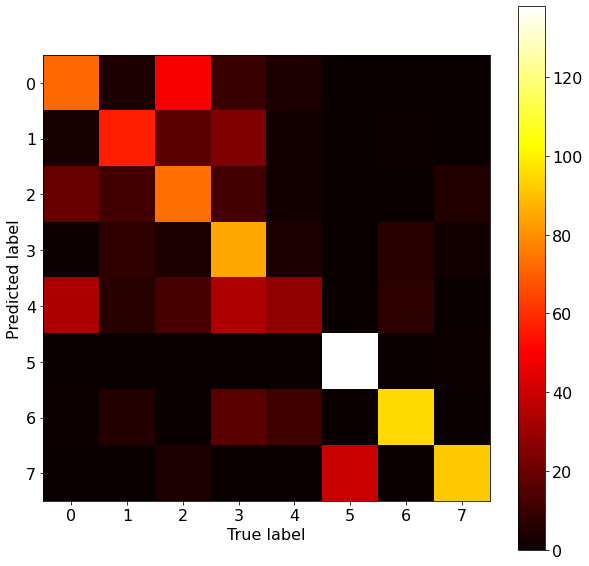

In [14]:
# Generate a new figure
plt.figure(figsize=(10,10))

# Display the confusion matrix
plt.imshow(mat, cmap='hot', interpolation='nearest')

# Add some anotation for the plot
plt.colorbar()
plt.xlabel('True label')
plt.ylabel('Predicted label')
plt.show()